# Intervention Layer Smoke Test
This notebook validates intervention -> event conversion and runner compatibility.

## A. Imports

In [1]:
import sys
from pathlib import Path

# Locate the repository root by searching for extensions/scenario_api
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'extensions' / 'scenario_api').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate extensions/scenario_api from current working directory')

extensions_dir = repo_root / 'extensions'
if str(extensions_dir) not in sys.path:
    sys.path.insert(0, str(extensions_dir))

from scenario_api import *


## B. Create ParameterIntervention

In [2]:
lockdown = create_parameter_intervention(
    name="lockdown",
    start=10,
    end=20,
    params={"relative_transmission": 0.8, "testing_rate": 0.3},
)
print(lockdown)


ParameterIntervention(name='lockdown', start=10, end=20, metadata={}, params={'relative_transmission': 0.8, 'testing_rate': 0.3})


## C. Convert Intervention to Events

In [3]:
base_params = {"relative_transmission": 1.2, "testing_rate": 0.1}
converted_events = intervention_to_events(lockdown, base_params=base_params)
print("Converted events:")
for ev in converted_events:
    print(ev)


Converted events:
TimelineEvent(time=10, action='set', target='relative_transmission', value=0.8, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'start'})
TimelineEvent(time=10, action='set', target='testing_rate', value=0.3, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'start'})
TimelineEvent(time=20, action='set', target='relative_transmission', value=1.2, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'end_restore'})
TimelineEvent(time=20, action='set', target='testing_rate', value=0.1, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'end_restore'})


## D. Attach Intervention to Scenario and Resolve

In [4]:
scenario = create_scenario(
    name="intervention_demo",
    base_params=base_params,
    interventions=[lockdown],
)
resolved = resolve_scenario(scenario)
print("events_by_time:")
for t in sorted(resolved.events_by_time):
    print(t, resolved.events_by_time[t])


events_by_time:
10 [TimelineEvent(time=10, action='set', target='relative_transmission', value=0.8, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'start'}), TimelineEvent(time=10, action='set', target='testing_rate', value=0.3, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'start'})]
20 [TimelineEvent(time=20, action='set', target='relative_transmission', value=1.2, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'end_restore'}), TimelineEvent(time=20, action='set', target='testing_rate', value=0.1, event_type='soft', metadata={'intervention': 'lockdown', 'phase': 'end_restore'})]


## E. Run and Compare Trajectory

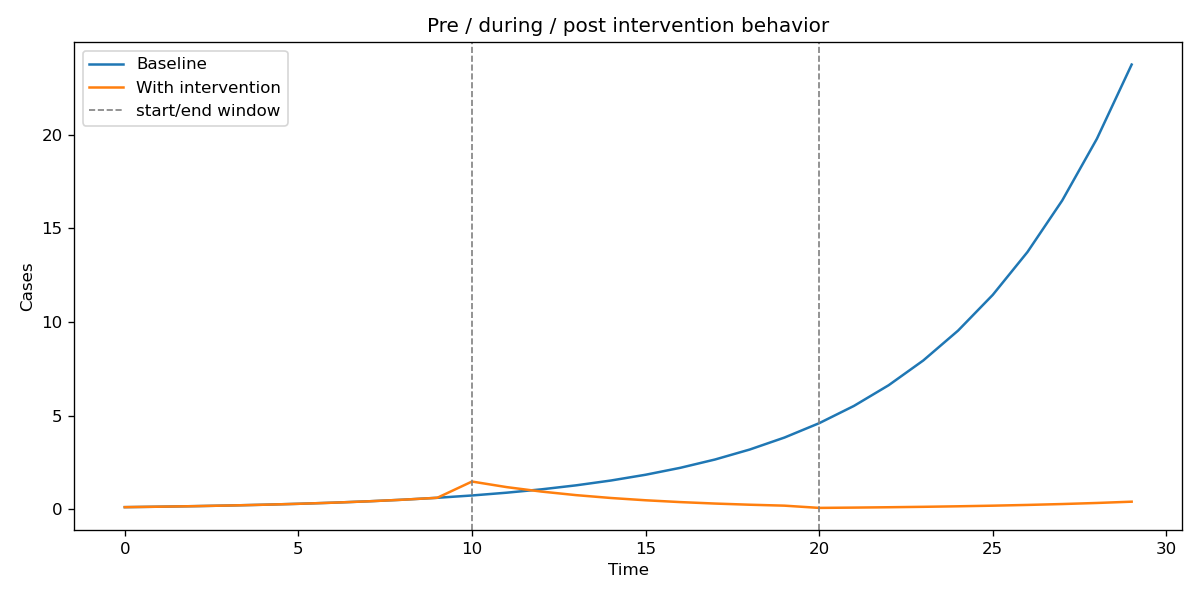

Values around intervention window:
8 0.5159780352
10 1.4860167413759997
15 0.48693796581408777
20 0.07977991631898018
22 0.11488307949933144


In [5]:
import io
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

baseline = resolve_scenario(create_scenario(name="baseline", base_params=base_params))
res_baseline = run_scenario(baseline, steps=30)
res_intervention = run_scenario(resolved, steps=30)

ts_baseline = result_to_timeseries(res_baseline, "cases")
ts_intervention = result_to_timeseries(res_intervention, "cases")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts_baseline.times, ts_baseline.values, label='Baseline')
ax.plot(ts_intervention.times, ts_intervention.values, label='With intervention')
ax.axvline(10, color='gray', linestyle='--', linewidth=1, label='start/end window')
ax.axvline(20, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('Cases')
ax.set_title('Pre / during / post intervention behavior')
ax.legend()
fig.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format='png', dpi=120)
plt.close(fig)
buf.seek(0)
display(Image(data=buf.read()))

print('Values around intervention window:')
for t in [8, 10, 15, 20, 22]:
    print(t, ts_intervention.values[t])
